<a href="https://colab.research.google.com/github/ojasvi-1705/Applied-Machine-Learning/blob/main/AML_EXP5_27_02_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uploading the file


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
uploaded = files.upload()


Saving GOOG.csv to GOOG (3).csv


In [ ]:
df = pd.read_csv('GOOG.csv')


Basic EDA


In [ ]:
df.shape

(2517, 7)

In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


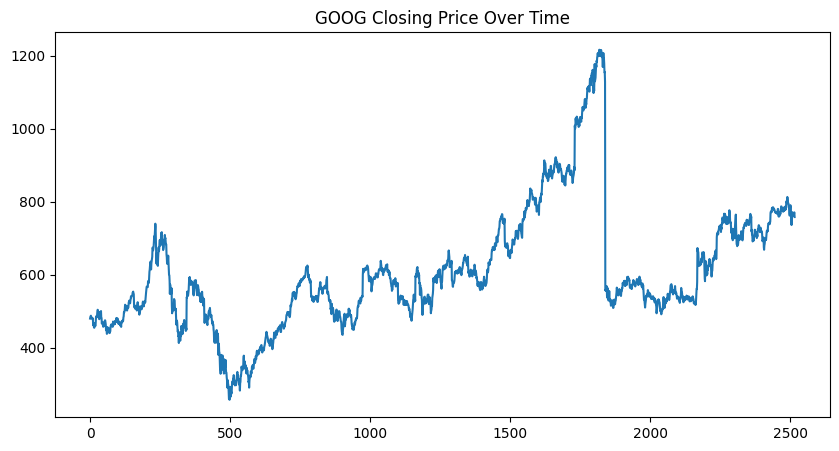

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("GOOG Closing Price Over Time")
plt.show()

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Sorting according to date

In [ ]:
if 'Date' in df.index.names:
    df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(by='Date')
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2006-12-01,242.082611,243.283112,238.356583,479.483612,239.502289,11304900
2006-12-04,240.598175,242.804901,238.779999,483.522522,241.519730,9836400
2006-12-05,242.789963,243.806152,241.539658,485.666626,242.590714,8236700
2006-12-06,242.570786,245.280624,241.355347,487.371948,243.442520,8933900
2006-12-07,244.199677,244.981750,240.309265,481.318573,240.418854,9363500


Basic Linear Regression

In [ ]:
x = df[['High', 'Low', 'Open', 'Volume']]
y = df[['Close']]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=False)

Linear Regression with Lag Function and moving Average

In [ ]:
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)

df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()

df = df.dropna()

In [ ]:
X_lagMa = df[['High','Low','Open','Volume','Close_lag1','Close_lag2', 'MA_5', 'MA_10']]
y_lagMa = df['Close']

Training the model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lagMa, y_lagMa, test_size=0.2, shuffle=False)

model_lag = LinearRegression()
model_lag.fit(X_train, y_train)

y_pred = model_lag.predict(X_test)


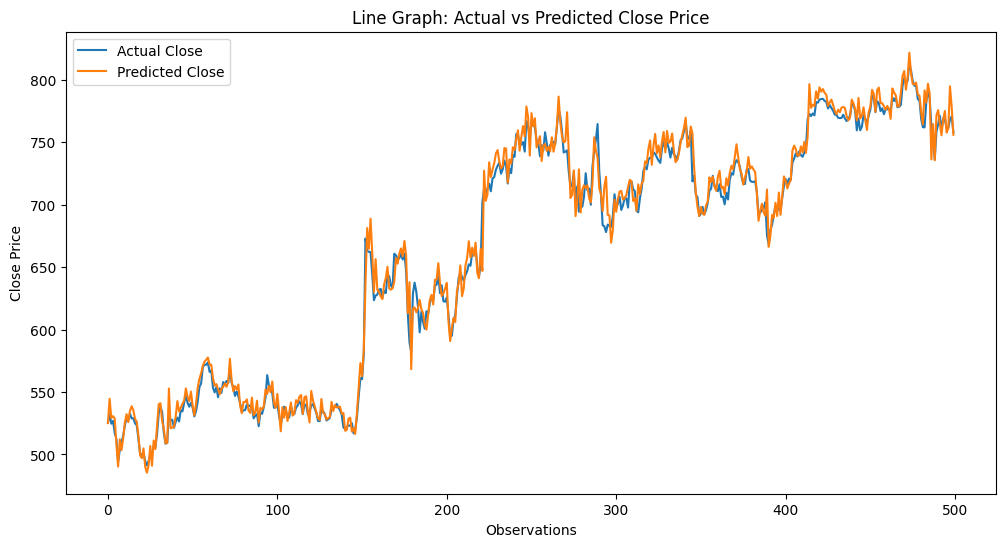

In [ ]:


plt.figure(figsize=(12,6))

# Actual values
plt.plot(range(len(y_test)), y_test.values, label="Actual Close")

# Predicted values
plt.plot(range(len(y_pred)), y_pred, label="Predicted Close")

plt.title("Line Graph: Actual vs Predicted Close Price")
plt.xlabel("Observations")
plt.ylabel("Close Price")
plt.legend()

plt.show()